EXPERIMENTAL RESULTS

In [1]:
import numpy as np
import random
import math
from itertools import permutations
import zipfile
import os
import shutil
import glob
from sklearn.model_selection import train_test_split

Load all types of generated instances

In [3]:
insert_new = np.load('results/insert_ls_1000_gens_NS2_0_85.npz')['data']
print(insert_new.shape)

swap_new = np.load('results/swap_ls_1000_gens_NS2_0_85.npz')['data']
print(swap_new.shape)

two_opt_new = np.load('results/two_opt_ls_1000_gens_NS2_0_85.npz')['data']
print(two_opt_new.shape)

insert_new_F = np.load('results/insert_ls_1000_gens_NS1_0_85.npz')['data']
print(insert_new_F.shape)

swap_new_F = np.load('results/swap_ls_1000_gens_NS1_0_85.npz')['data']
print(swap_new_F.shape)

two_opt_new_F = np.load('results/two_opt_ls_1000_gens_NS1_0_85.npz')['data']
print(two_opt_new_F.shape)

(3277, 20, 20)
(1575, 20, 20)
(483, 20, 20)
(2222, 20, 20)
(4018, 20, 20)
(82, 20, 20)


Set seed for reproducibility

In [4]:
import torch

def set_global_seed(seed=42):
    random.seed(seed)

    np.random.seed(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    torch.use_deterministic_algorithms(True)
    
    os.environ['PYTHONHASHSEED'] = str(seed)
    os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'

set_global_seed(42)


Define LS algorithms

In [5]:
set_global_seed(42)

from numba import njit

@njit
def profit_permutation(A, sigma):
    total = 0.0
    N = len(sigma)
    for i in range(N):
        for j in range(i + 1, N):
            total += A[sigma[i], sigma[j]]
    return total
    
def profit(A, algorithm):
    rand_indices = [np.random.randint(0, i+1) for i in range(19, 0, -1)]
    sigma = np.array(algorithm(A, rand_indices))
    idx = sigma.astype(int)

    A_sub = A[np.ix_(idx, idx)]
    total_sum = np.sum(np.triu(A_sub, k=1))
    return total_sum

In [6]:
from numba import njit

@njit
def two_opt_ls(A, rand_indices):
    N = A.shape[0]
    sigma = np.arange(N)
    for i in range(N-1, 0, -1):
        j = rand_indices[N - 1 - i]
        sigma[i], sigma[j] = sigma[j], sigma[i]

    a = profit_permutation(A, sigma)
    improvement = True

    while improvement:
        improvement = False
        for i in range(N):
            for j in range(i+1, N):
                sigma[i:j+1] = sigma[i:j+1][::-1]
                b = profit_permutation(A, sigma)
                if b > a:
                    a = b
                    improvement = True
                    break
                else:
                    sigma[i:j+1] = sigma[i:j+1][::-1]
            if improvement:
                break

    return sigma

@njit
def swap_ls(A, rand_indices):
    N = A.shape[0]

    sigma = np.arange(N)
    for i in range(N - 1, 0, -1):
        j = rand_indices[N - 1 - i]
        sigma[i], sigma[j] = sigma[j], sigma[i]

    current_profit = profit_permutation(A, sigma)
    improvement = True

    while improvement:
        improvement = False
        for i in range(N):
            for j in range(i + 1, N):
                sigma[i], sigma[j] = sigma[j], sigma[i]
                new_profit = profit_permutation(A, sigma)

                if new_profit > current_profit:
                    current_profit = new_profit
                    improvement = True
                    break
                else:
                    sigma[i], sigma[j] = sigma[j], sigma[i]
            if improvement:
                break

    return sigma

@njit
def insert_ls(A, rand_indices):
    N = A.shape[0]
    sigma = np.arange(N)
    for i in range(N-1, 0, -1):
        j = rand_indices[N - 1 - i]
        sigma[i], sigma[j] = sigma[j], sigma[i]

    a = profit_permutation(A, sigma)
    improvement = True

    while improvement:
        improvement = False
        for i in range(N):
            for j in range(N):
                if i == j:
                    continue
                sigma_copy = sigma.copy()
                temp = sigma_copy[i]
                if i < j:
                    for k in range(i, j):
                        sigma_copy[k] = sigma_copy[k+1]
                else:
                    for k in range(i, j, -1):
                        sigma_copy[k] = sigma_copy[k-1]
                sigma_copy[j] = temp

                b = profit_permutation(A, sigma_copy)
                if b > a:
                    sigma = sigma_copy
                    a = b
                    improvement = True
                    break
            if improvement:
                break

    return sigma

Load benchmark instances

In [7]:
set_global_seed(42)

lolib = np.load('benchmark/LOLIB_instances.npz')['data']
print(lolib.shape)
random_instances = np.load('benchmark/random_instances.npz')['data']
print(random_instances.shape)
instances = np.load('benchmark/benchmark_instances.npz')['data']
print(instances.shape)
train_3, test_3 = train_test_split(instances, test_size=0.2, random_state=42)
train = train_3
validation = test_3
test = test_3
training_set, population_set = train_test_split(train,test_size=50 / len(train),random_state=42)

set_global_seed(42)
print(train.shape)

(3188, 20, 20)
(1500, 20, 20)
(4688, 20, 20)
(3750, 20, 20)


Define and train the autoencoder

In [8]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class Autoencoder(nn.Module):
    def __init__(self, input_dim, latent_dim, hidden_dim=80):
        super(Autoencoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, latent_dim),
            nn.Tanh()
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, input_dim),
            nn.Tanh()
        )

    def forward(self, x):
        z = self.encoder(x)
        out = self.decoder(z)
        return out

def ae_loss(recon_x, x):
    return F.mse_loss(recon_x, x, reduction='mean')

def train_autoencoder(model, data, epochs=50, batch_size=64, lr=1e-3):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    for epoch in range(epochs):
        model.train()
        for i in range(0, len(data), batch_size):
            batch = data[i:i+batch_size]
            optimizer.zero_grad()
            recon = model(batch)
            loss = ae_loss(recon, batch)
            loss.backward()
            optimizer.step()

def get_ae_latents(model, data, batch_size=64):
    model.eval()
    latents = []
    with torch.no_grad():
        for i in range(0, len(data), batch_size):
            batch = data[i:i+batch_size]
            z = model.encoder(batch)
            latents.append(z)
    return torch.cat(latents, dim=0)

def train_autoencoder_from_matrices(matrix_data, N, latent_dim=12, hidden_dim=80, epochs=15, batch_size=32, lr=1e-3):
    matrix_array = np.array(matrix_data, dtype=np.float32)

    mask = ~np.eye(N, dtype=bool)
    masked_data = matrix_array[:, mask]

    flat_data = masked_data.reshape(masked_data.shape[0], -1)

    tensor_data = torch.tensor(flat_data, dtype=torch.float32)

    input_dim = tensor_data.shape[1]
    ae_model = Autoencoder(input_dim=input_dim, latent_dim=latent_dim, hidden_dim=hidden_dim)
    train_autoencoder(ae_model, tensor_data, epochs=epochs, batch_size=batch_size, lr=lr)

    latents = get_ae_latents(ae_model, tensor_data, batch_size=batch_size)

    return latents, ae_model

set_global_seed(42)
z, ae_model = train_autoencoder_from_matrices(train, 20)
print(np.max(z.numpy()))
print(np.mean(z.numpy()))

0.9428536
-0.08491557


Compute the MSE for the trained autoencoder + for the untrained autoencoder

In [9]:
import torch
import torch.nn.functional as F

@torch.no_grad()
def dataset_mse_from_matrices(model, matrices, N, batch_size=64):
    arr = np.array(matrices, dtype=np.float32)
    mask = ~np.eye(N, dtype=bool)
    flat = arr[:, mask].reshape(arr.shape[0], -1)
    X = torch.tensor(flat, dtype=torch.float32)

    model.eval()
    se_sum, n_elems = 0.0, 0
    for i in range(0, len(X), batch_size):
        b = X[i:i+batch_size]
        r = model(b)
        se_sum += F.mse_loss(r, b, reduction='sum').item()
        n_elems += b.numel()
    return se_sum / n_elems

val_mse = dataset_mse_from_matrices(ae_model, test_3, N=20)

input_dim = 20*20 - 20
latent_dim = ae_model.encoder[2].out_features
hidden_dim = ae_model.encoder[0].out_features

torch.manual_seed(0)
rand_ae = Autoencoder(input_dim=input_dim, latent_dim=latent_dim, hidden_dim=hidden_dim)

rand_val_mse = dataset_mse_from_matrices(rand_ae, test_3, N=20)
print(f"Trained AE Validation MSE: {val_mse:.8f}")
print(f"Random AE Validation MSE: {rand_val_mse:.8f}")


Trained AE Validation MSE: 0.13711979
Random AE Validation MSE: 0.62634672


Define the feature extraction functions for $NS^{F}$ and $NS^{AE}$

In [10]:
set_global_seed(42)

@njit
def compute_descriptors_NS_F(solution_set):
    pop_size, N, _ = solution_set.shape
    data_matrix = np.zeros((pop_size, 12))

    tril_i = []
    tril_j = []
    for i in range(N):
        for j in range(i):
            tril_i.append(i)
            tril_j.append(j)
    tril_i = np.array(tril_i)
    tril_j = np.array(tril_j)

    for t in range(pop_size):
        A = solution_set[t].copy()

        for i in range(N):
            A[i, i] = 0

        data_matrix[t, 0] = np.mean(A)
        data_matrix[t, 1] = np.var(A)
        data_matrix[t, 2] = np.max(A)
        data_matrix[t, 3] = np.min(A)

        B = np.empty(len(tril_i))
        for idx in range(len(tril_i)):
            i = tril_i[idx]
            j = tril_j[idx]
            B[idx] = (A[i, j] - A[j, i]) / 2

        if B.size > 0:
            data_matrix[t, 4] = np.mean(B)
            data_matrix[t, 5] = np.var(B)
            data_matrix[t, 6] = np.max(B)
            data_matrix[t, 7] = np.min(B)
        else:
            data_matrix[t, 4:8] = 0

        row_col_diff = np.empty(N)
        for i in range(N):
            row_sum = 0.0
            col_sum = 0.0
            for j in range(N):
                row_sum += A[i, j]
                col_sum += A[j, i]
            row_col_diff[i] = (row_sum - col_sum) / (2 * N)

        data_matrix[t, 8] = np.mean(row_col_diff)
        data_matrix[t, 9] = np.var(row_col_diff)
        data_matrix[t,10] = np.max(row_col_diff)
        data_matrix[t,11] = np.min(row_col_diff)

    return data_matrix

In [11]:
set_global_seed(42)

def compute_descriptors_NS_AE(solution_set):

    N = solution_set.shape[1]
    mask = ~np.eye(N, dtype=bool)
    masked_data = solution_set[:,mask]
    flat = masked_data.reshape(masked_data.shape[0], -1)
    tens = torch.tensor(np.array(flat), dtype=torch.float32)
    ae_model.eval()
    with torch.no_grad():
        data_matrix = ae_model.encoder(tens).cpu().numpy().astype(np.float32)
    return data_matrix

Functions used to define and use the feature-based and autoencoder-based PCA spaces

In [ ]:
set_global_seed(42)

import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

def fit_pca_reference(*data_matrices, x=0, y=0, y_2=0, padding=0.1, flip_x=True):
    matrix = np.vstack(data_matrices).reshape(-1, data_matrices[0].shape[1])
    scaler = StandardScaler()
    matrix_std = scaler.fit_transform(matrix)

    pca = PCA(n_components=2, svd_solver='full', random_state=42)
    reduced_data = pca.fit_transform(matrix_std)

    signs = np.sign(pca.components_.sum(axis=1))
    signs[signs == 0] = 1

    if flip_x:
        signs[0] *= -1

    pca.components_ *= signs[:, None]
    reduced_data *= signs

    x_min, x_max = reduced_data[:, 0].min(), reduced_data[:, 0].max()
    y_min, y_max = reduced_data[:, 1].min(), reduced_data[:, 1].max()

    x_range = x_max - x_min
    y_range = y_max - y_min

    x_min -= x_range * padding/4
    x_max += x_range * padding/4 + x
    y_min -= y_range * padding + y
    y_max += y_range * padding + y_2

    axis_limits = (x_min, x_max, y_min, y_max)

    return scaler, pca, axis_limits


def plot_with_fitted_pca(name, *data_matrices, scaler, pca, axis_limits=None, labels=None, title="PCA Projection"):
    sizes = [len(dm) for dm in data_matrices]
    cumulative_sizes = np.cumsum([0] + sizes)

    matrix = np.vstack(data_matrices).reshape(len(np.vstack(data_matrices)), -1)
    matrix_std = scaler.transform(matrix)
    reduced_data = pca.transform(matrix_std)

    plt.figure(figsize=(8, 5))
    default_colors = ['#1f77b4', '#ff7f0e', '#d62728', '#2ca02c', '#9467bd', '#8c564b']
    default_markers = ['o', '*', 's', 'P', '^', 'x']

    for i in range(len(data_matrices)):
        group = reduced_data[cumulative_sizes[i]:cumulative_sizes[i+1], :]
        label = labels[i] if labels and i < len(labels) else f"Grupo {i+1}"
        color = default_colors[i % len(default_colors)]
        marker = default_markers[i % len(default_markers)]
        plt.scatter(group[:, 0], group[:, 1], s=0.8, marker=marker, label=label, color=color)

    if axis_limits:
        x_min, x_max, y_min, y_max = axis_limits
        plt.xlim(x_min, x_max)
        plt.ylim(y_min, y_max)


    #plt.title(title, fontsize=14)
    plt.legend(loc='best', frameon=True)
    plt.grid(False)
    plt.tight_layout()
    plt.show()


Fix both spaces

In [16]:
set_global_seed(42)

scaler, pca, axis_limits = fit_pca_reference(compute_descriptors_NS_AE(training_set), y_2=0.75)

print(axis_limits)

scaler_2, pca_2, axis_limits_2 = fit_pca_reference(compute_descriptors_NS_F(training_set), x=2.5, y=0.5, flip_x=False)

print(axis_limits_2)

(np.float32(-2.9230795), np.float32(4.5110664), np.float32(-4.2185287), np.float32(8.783937))
(np.float64(-4.299453574089672), np.float64(8.973528677413999), np.float64(-5.016275790636797), np.float64(6.822052677356283))


Random instances for reference

In [17]:
import numpy as np

def generate_beta_instances(num_instances=500, shape=(20, 20)):
    instances = np.random.beta(2, 5, size=(num_instances, *shape))
    instances = instances * 2 - 1
    return instances


def generate_uniform_instances(num_instances=500, shape=(20, 20)):
    instances = np.random.uniform(-1, 1, size=(num_instances, *shape))
    return instances


def generate_normal_instances(num_instances=500, shape=(20, 20), sigma=0.3):
    instances = np.random.normal(0, sigma, size=(num_instances, *shape))
    instances = np.clip(instances, -1, 1)
    return instances

beta_data = generate_beta_instances()
uniform_data = generate_uniform_instances()
normal_data = generate_normal_instances()

print(beta_data.shape)
print(uniform_data.shape)
print(normal_data.shape)

(500, 20, 20)
(500, 20, 20)
(500, 20, 20)


Plots $NS^{F}$ vs $NS^{AE}$

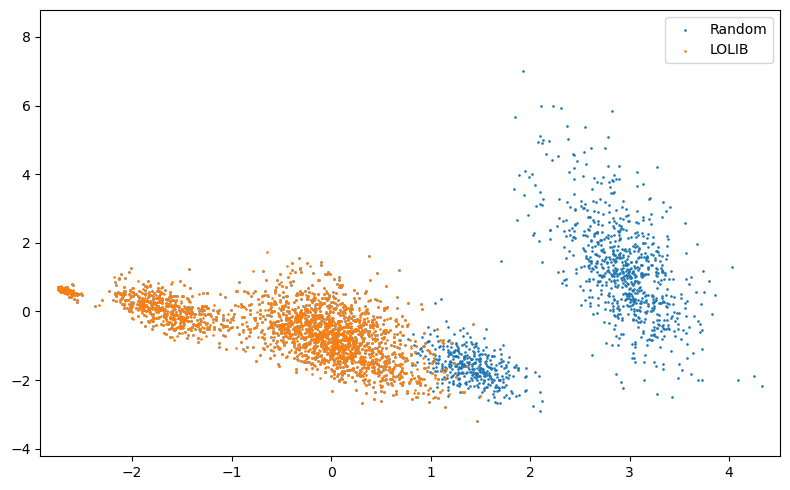

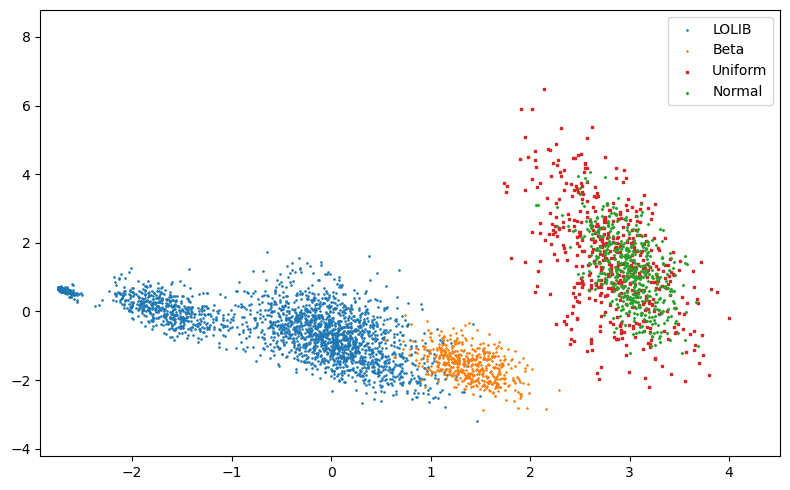

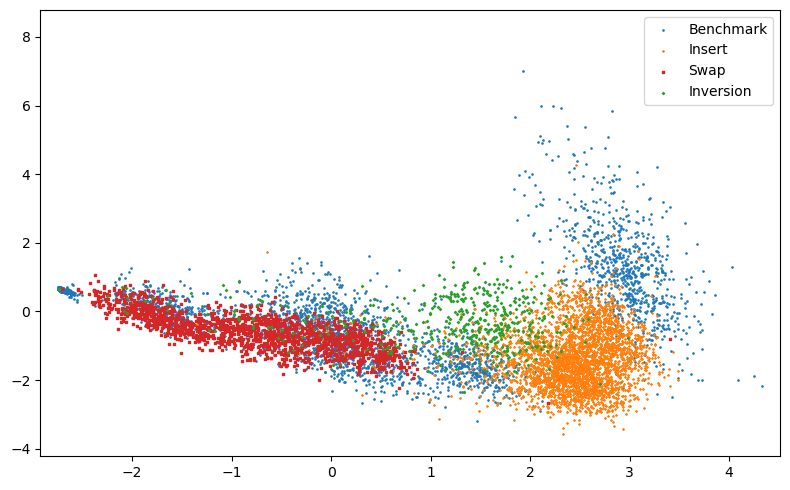

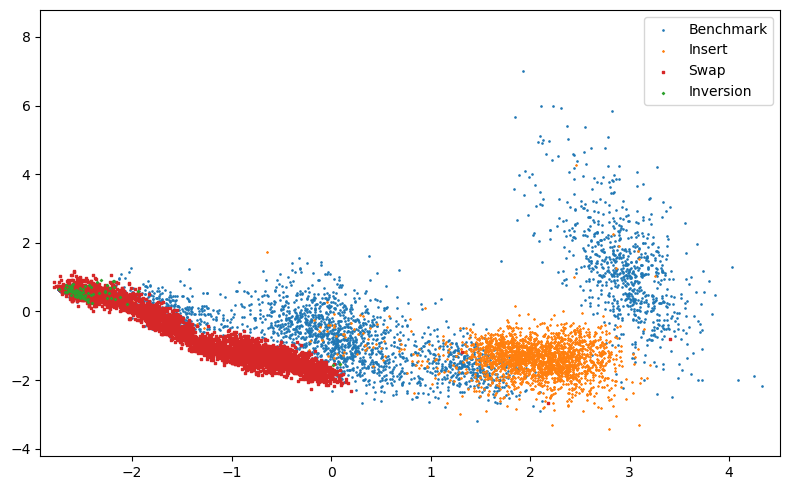

In [18]:
set_global_seed(42)

plot_with_fitted_pca("lolib", compute_descriptors_NS_AE(training_set), compute_descriptors_NS_AE(lolib), scaler=scaler, pca=pca, axis_limits=axis_limits, labels=["Random", "LOLIB"], title="Autoencoder-based descriptors base PCA")

plot_with_fitted_pca("Benchmark instances NS_AE", compute_descriptors_NS_AE(lolib), compute_descriptors_NS_AE(beta_data),compute_descriptors_NS_AE(uniform_data),compute_descriptors_NS_AE(normal_data),
                     scaler=scaler, pca=pca, axis_limits=axis_limits, labels=["LOLIB", "Beta", "Uniform", "Normal"], title=r"Benchmark instances in the autoencoder-based PCA space")

plot_with_fitted_pca("1000_IP_NS_AE_in_NS_AE_new", compute_descriptors_NS_AE(training_set), compute_descriptors_NS_AE(insert_new),compute_descriptors_NS_AE(swap_new),compute_descriptors_NS_AE(two_opt_new),
                     scaler=scaler, pca=pca, axis_limits=axis_limits, labels=["Benchmark", "Insert", "Swap", "Inversion"], title=r"1000 generations of $NS^{AE}$ in the autoencoder-based PCA space")

plot_with_fitted_pca("1000_IP_NS_F_in_NS_AE_new", compute_descriptors_NS_AE(training_set), compute_descriptors_NS_AE(insert_new_F),compute_descriptors_NS_AE(swap_new_F),compute_descriptors_NS_AE(two_opt_new_F),
                     scaler=scaler, pca=pca, axis_limits=axis_limits, labels=["Benchmark", "Insert", "Swap", "Inversion"], title=r"1000 generations of $NS^{F}$ in the autoencoder-based PCA space")

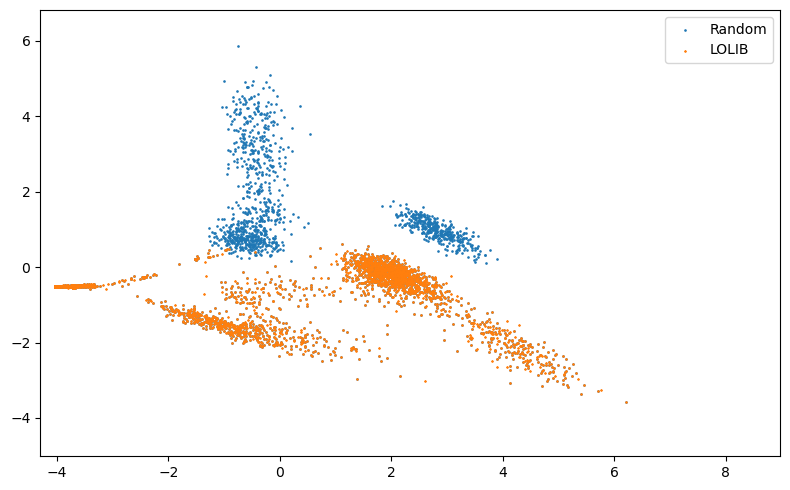

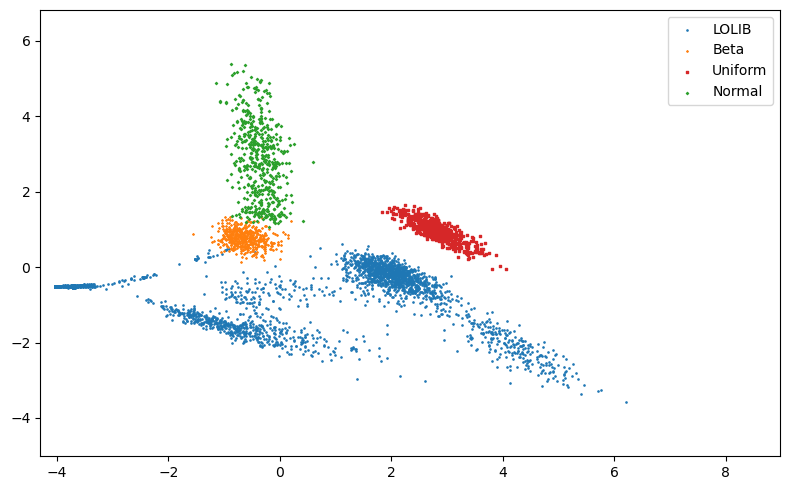

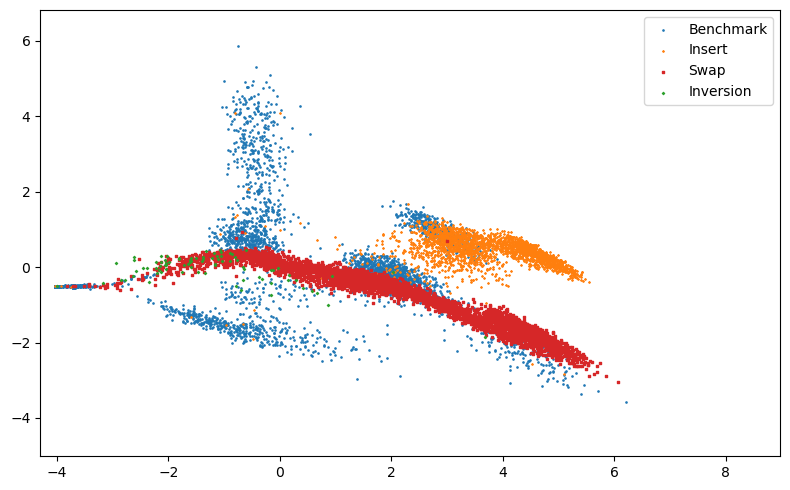

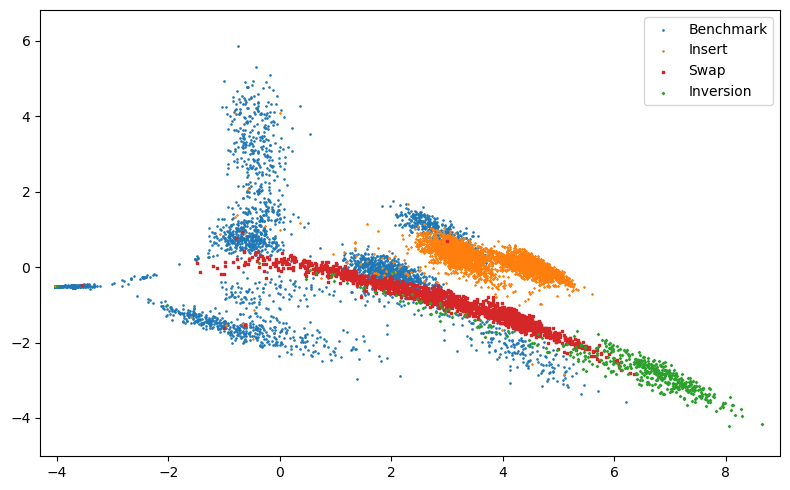

In [19]:
set_global_seed(42)

plot_with_fitted_pca("lolib_NS_F", compute_descriptors_NS_F(training_set), compute_descriptors_NS_F(lolib), scaler=scaler_2, pca=pca_2, axis_limits=axis_limits_2, labels=["Random", "LOLIB"], title="Feature-based descriptors base PCA")

plot_with_fitted_pca("Benchmark instances NS_F", compute_descriptors_NS_F(lolib), compute_descriptors_NS_F(beta_data),compute_descriptors_NS_F(uniform_data),compute_descriptors_NS_F(normal_data),
                     scaler=scaler_2, pca=pca_2, axis_limits=axis_limits_2, labels=["LOLIB", "Beta", "Uniform", "Normal"], title=r"Benchmark instances in the feature-based PCA space")

plot_with_fitted_pca("1000_IP_NS_F_in_NS_F_new", compute_descriptors_NS_F(training_set), compute_descriptors_NS_F(insert_new_F),compute_descriptors_NS_F(swap_new_F),compute_descriptors_NS_F(two_opt_new_F),
                     scaler=scaler_2, pca=pca_2, axis_limits=axis_limits_2, labels=["Benchmark", "Insert", "Swap", "Inversion"], title=r"1000 generations of $NS^{F}$ in the feature-based PCA space")

plot_with_fitted_pca("1000_IP_NS_AE_in_NS_F_new", compute_descriptors_NS_F(training_set), compute_descriptors_NS_F(insert_new),compute_descriptors_NS_F(swap_new),compute_descriptors_NS_F(two_opt_new),
                     scaler=scaler_2, pca=pca_2, axis_limits=axis_limits_2, labels=["Benchmark", "Insert", "Swap", "Inversion"], title=r"1000 generations of $NS^{AE}$ in the feature-based PCA space")

Load data for different $\phi$

In [23]:
descriptor_dict = {}

methods = ['insert', 'swap', 'two_opt']
suffixes = ['0', '0_1', '0_25', '0_4', '0_55', '0_7', '1']

for method in methods:
    for suffix in suffixes:
        key = f'{method}_ls_1000_gens_NS2_{suffix}'
        filename = f'changing-phi/{key}.npz'
        try:
            perturbed_data = np.load(filename)['data']
            
            descriptors = compute_descriptors_NS_AE(perturbed_data)
            
            descriptor_dict[key] = descriptors
            print(f"{key}: {descriptors.shape}")
        except Exception as e:
            print(f"Error in {key}: {e}")


operator_groups = {
    'insert': [k for k in descriptor_dict if k.startswith('insert')],
    'swap': [k for k in descriptor_dict if k.startswith('swap')],
    'two_opt': [k for k in descriptor_dict if k.startswith('two_opt')],
}

insert_ls_1000_gens_NS2_0: (42481, 12)
insert_ls_1000_gens_NS2_0_1: (42992, 12)
insert_ls_1000_gens_NS2_0_25: (40369, 12)
insert_ls_1000_gens_NS2_0_4: (34765, 12)
insert_ls_1000_gens_NS2_0_55: (18748, 12)
insert_ls_1000_gens_NS2_0_7: (9841, 12)
insert_ls_1000_gens_NS2_1: (1153, 12)
swap_ls_1000_gens_NS2_0: (43, 12)
swap_ls_1000_gens_NS2_0_1: (73, 12)
swap_ls_1000_gens_NS2_0_25: (118, 12)
swap_ls_1000_gens_NS2_0_4: (1364, 12)
swap_ls_1000_gens_NS2_0_55: (1634, 12)
swap_ls_1000_gens_NS2_0_7: (4513, 12)
swap_ls_1000_gens_NS2_1: (314, 12)
two_opt_ls_1000_gens_NS2_0: (3, 12)
two_opt_ls_1000_gens_NS2_0_1: (5, 12)
two_opt_ls_1000_gens_NS2_0_25: (8, 12)
two_opt_ls_1000_gens_NS2_0_4: (128, 12)
two_opt_ls_1000_gens_NS2_0_55: (794, 12)
two_opt_ls_1000_gens_NS2_0_7: (491, 12)
two_opt_ls_1000_gens_NS2_1: (314, 12)


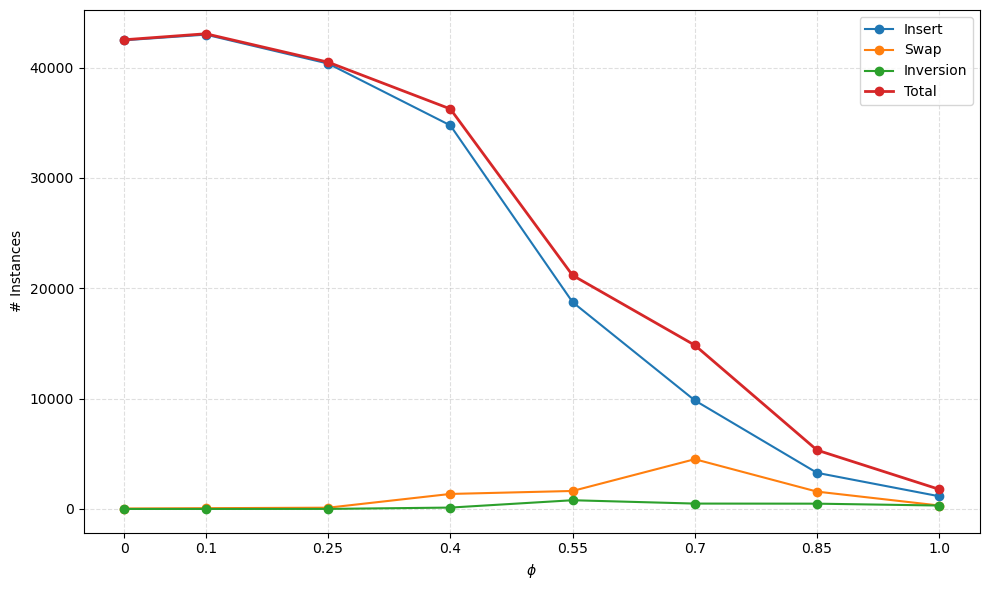

In [25]:
import matplotlib.pyplot as plt

xs = [0, 0.1, 0.25, 0.4, 0.55, 0.7, 0.85, 1.0]

insert = {
    0.0: 42481,
    0.1: 42992,
    0.25: 40369,
    0.4: 34765,
    0.55: 18748,
    0.7: 9841,
    0.85: 3277,
    1.0: 1153,
}

swap = {
    0.0: 43,
    0.1: 73,
    0.25: 118,
    0.4: 1364,
    0.55: 1634,
    0.7: 4513,
    0.85: 1575,
    1.0: 314,
}

two_opt = {
    0.0: 3,
    0.1: 5,
    0.25: 8,
    0.4: 128,
    0.55: 794,
    0.7: 491,
    0.85: 483,
    1.0: 314,
}

y_insert = [insert.get(x, np.nan) for x in xs]
y_swap   = [swap.get(x, np.nan) for x in xs]
y_two    = [two_opt.get(x, np.nan) for x in xs]

y_total = list(np.nansum([y_insert, y_swap, y_two], axis=0))

plt.figure(figsize=(10, 6))

plt.plot(xs, y_insert, marker='o', label='Insert')
plt.plot(xs, y_swap, marker='o', label='Swap')
plt.plot(xs, y_two, marker='o', label='Inversion')
plt.plot(xs, y_total, marker='o', linewidth=2, label='Total')

plt.xticks(xs, [str(x) for x in xs])
plt.xlabel(r'$\phi$')
plt.ylabel('# Instances')
#plt.title('Comparison of the amount of instances generated for each LS algorithm')
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()

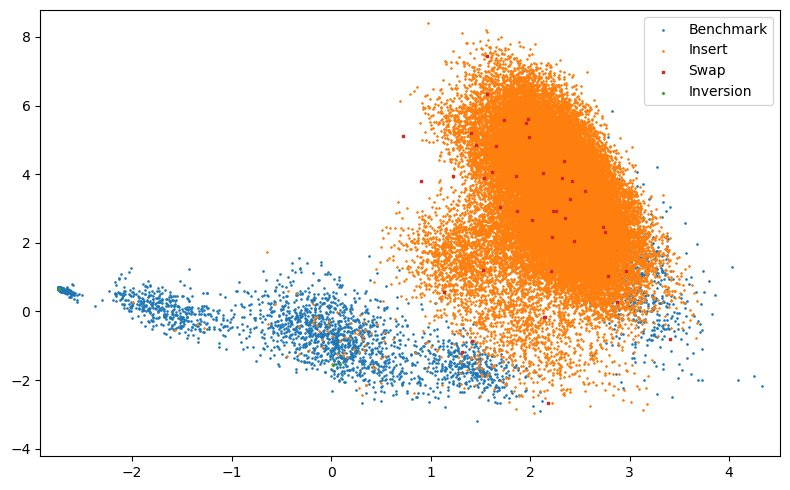

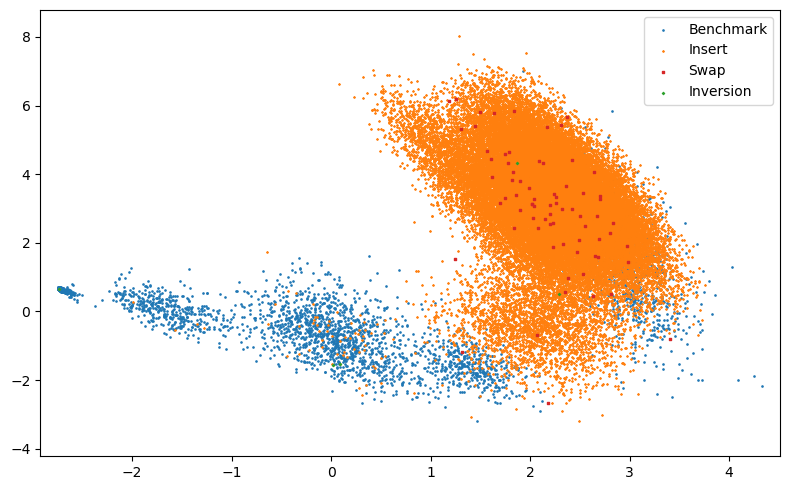

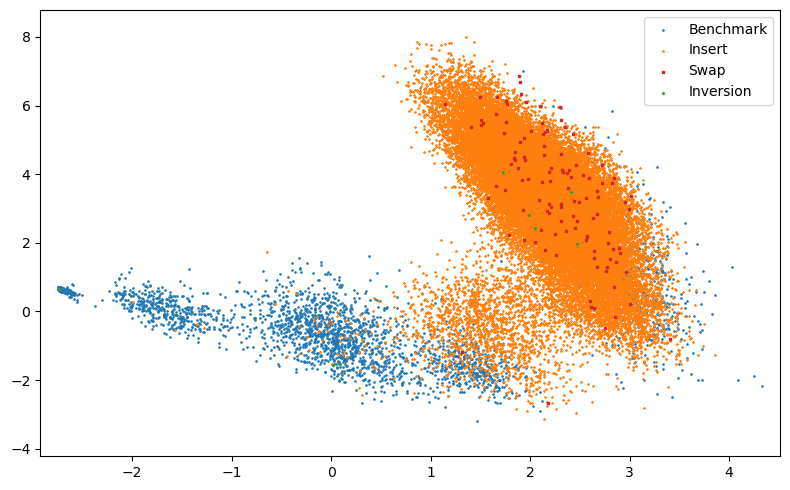

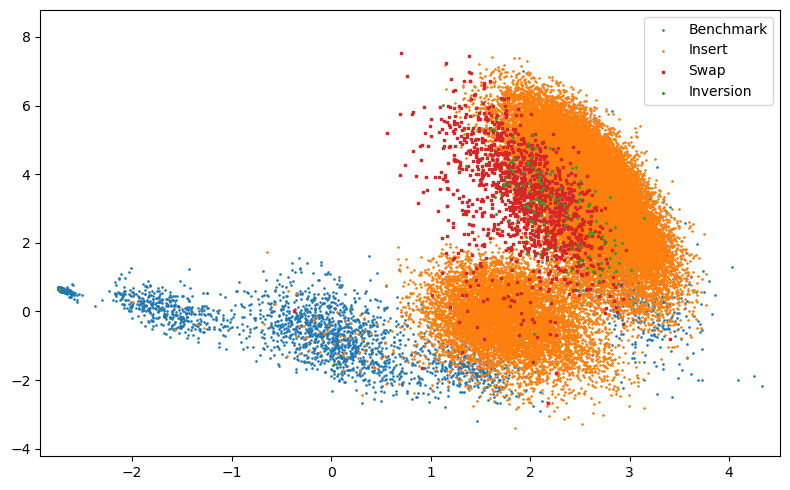

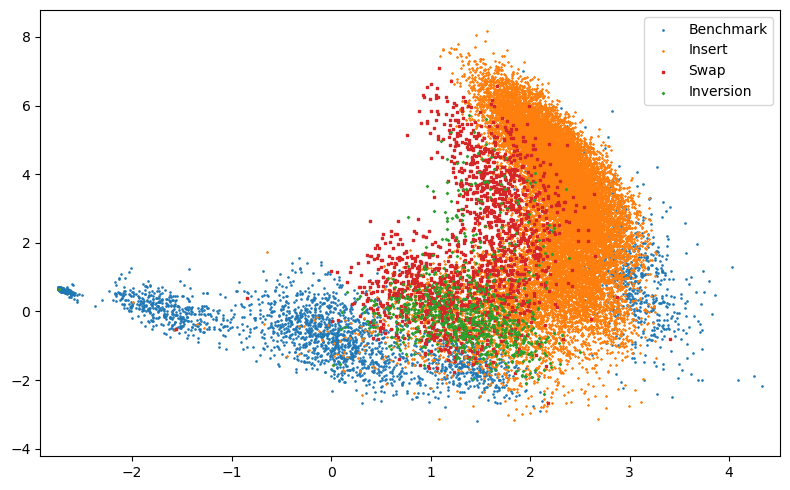

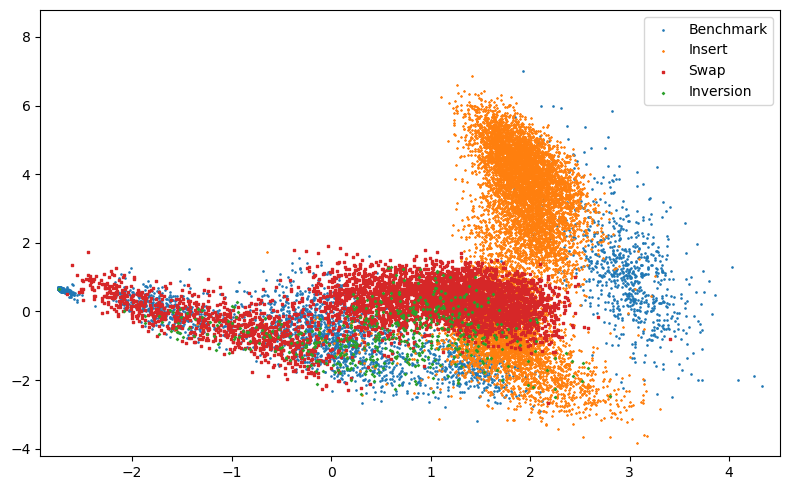

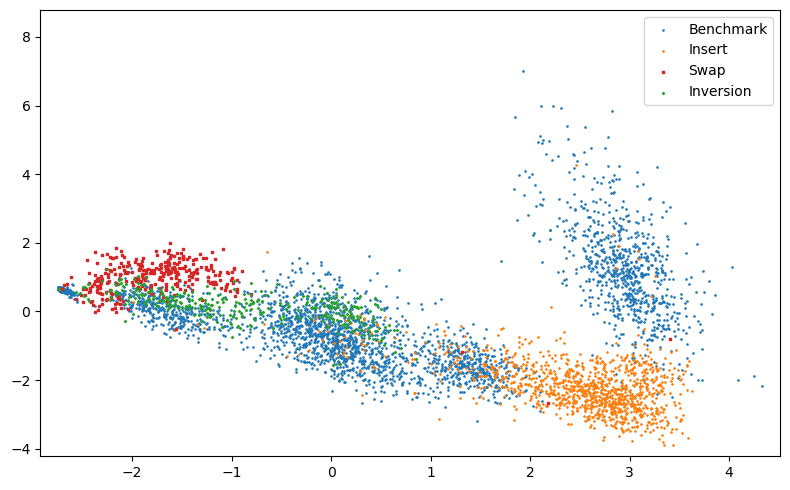

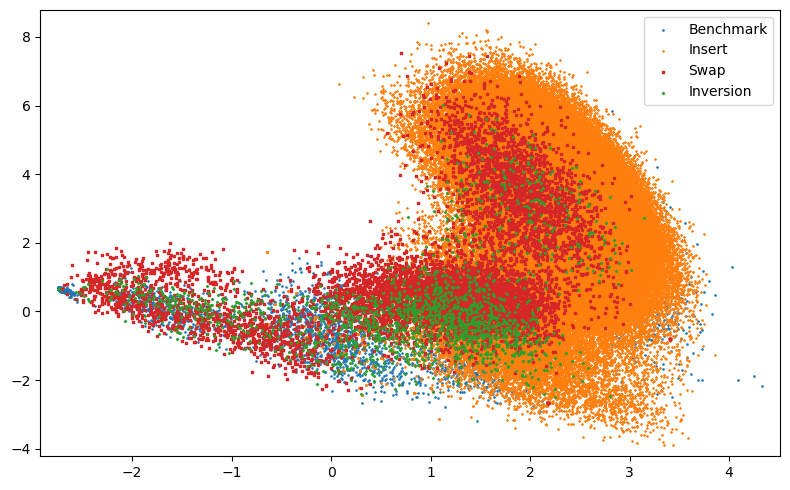

In [26]:
def group_by_operator(descriptor_dict, keys):
    return np.concatenate([descriptor_dict[k] for k in keys if k in descriptor_dict])

original_data = compute_descriptors_NS_AE(training_set)

for i in range(7):
    suffix = ['0', '0_1', '0_25', '0_4', '0_55', '0_7', '1'][i]
    number = ['0', '0.1', '0.25', '0.4', '0.55', '0.7', '1'][i]
    plot_with_fitted_pca(suffix,
        original_data,
        *[
            group_by_operator(descriptor_dict, [f'{method}_ls_1000_gens_NS2_{suffix}'])
            for method in operator_groups.keys()
        ],
        scaler=scaler,
        pca=pca,
        axis_limits=axis_limits,
        labels=['Benchmark','Insert','Swap','Inversion'],
        title=f"Generated instances for $\phi$={number}"
    )

def group_by_operator(descriptor_dict, keys):
    return np.concatenate([descriptor_dict[k] for k in keys if k in descriptor_dict])

original_data = compute_descriptors_NS_AE(training_set)

insert_all  = group_by_operator(descriptor_dict, operator_groups['insert'])
swap_all    = group_by_operator(descriptor_dict, operator_groups['swap'])
twoopt_all  = group_by_operator(descriptor_dict, operator_groups['two_opt'])

plot_with_fitted_pca(
    "all_phi",
    original_data,
    insert_all,
    swap_all,
    twoopt_all,
    scaler=scaler,
    pca=pca,
    axis_limits=axis_limits,
    labels=['Benchmark', 'Insert', 'Swap', 'Inversion'],
    title=r"Generated instances for all $\phi$"
)

Plots for different $\phi$ values

Define U metric

In [27]:
from scipy.spatial.distance import jensenshannon
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

set_global_seed(42)

def compute_U_metric(descriptors, scaler, pca, grid_size=40, xlim=None, ylim=None):
    descriptors_scaled = scaler.transform(descriptors)
    delta = pca.transform(descriptors_scaled)

    if xlim is None or ylim is None:
        raise ValueError("xlim and ylim must be provided to ensure consistent PCA area.")

    xmin, xmax = xlim
    ymin, ymax = ylim

    delta_norm = np.empty_like(delta)
    delta_norm[:, 0] = (delta[:, 0] - xmin) / (xmax - xmin + 1e-10)
    delta_norm[:, 1] = (delta[:, 1] - ymin) / (ymax - ymin + 1e-10)

    delta_norm = np.clip(delta_norm, 0, 1)

    grid_counts = np.zeros((grid_size, grid_size))
    for x, y in delta_norm:
        i = min(int(x * grid_size), grid_size - 1)
        j = min(int(y * grid_size), grid_size - 1)
        grid_counts[i, j] += 1

    P_delta = grid_counts.flatten() / np.sum(grid_counts)

    UD = np.ones_like(P_delta) / len(P_delta)

    jsd = jensenshannon(P_delta, UD, base=2)**2
    U_score = 1.0 - jsd

    return U_score

Compute U metric $NS^{F}$ vs $NS^{AE}$

In [28]:
set_global_seed(42)

xlim = axis_limits[0:2]
ylim = axis_limits[2:4]
xlim_2 = axis_limits_2[0:2]
ylim_2 = axis_limits_2[2:4]

descriptors = compute_descriptors_NS_F(np.concatenate((insert_new_F, swap_new_F, two_opt_new_F)))
U_1 = compute_U_metric(descriptors, scaler_2, pca_2, xlim=xlim_2, ylim=ylim_2)
print("U metric 1000 new NS_F in NS_F no benchmark:", U_1)

descriptors = compute_descriptors_NS_F(np.concatenate((insert_new, swap_new, two_opt_new)))
U_3 = compute_U_metric(descriptors, scaler_2, pca_2, xlim=xlim_2, ylim=ylim_2)
print("U metric 1000 new NS_AE in NS_F no benchmark:", U_3)

descriptors = compute_descriptors_NS_AE(np.concatenate((insert_new_F, swap_new_F, two_opt_new_F)))
U_2 = compute_U_metric(descriptors, scaler, pca, xlim=xlim, ylim=ylim)
print("U metric 1000 new NS_F in NS_AE no benchmark:", U_2)

descriptors = compute_descriptors_NS_AE(np.concatenate((insert_new, swap_new, two_opt_new)))
U_4 = compute_U_metric(descriptors, scaler, pca, xlim=xlim, ylim=ylim)
print("U metric 1000 new NS_AE in NS_AE no benchmark:", U_4)

A_1=U_1-U_3
A_2=U_4-U_2
print(A_1)
print(A_2)
print(A_2/A_1)

descriptors = compute_descriptors_NS_F(np.concatenate((training_set, insert_new_F, swap_new_F, two_opt_new_F)))
U_5 = compute_U_metric(descriptors, scaler_2, pca_2, xlim=xlim_2, ylim=ylim_2)
print("U metric 1000 new NS_F in NS_F:", U_5)

descriptors = compute_descriptors_NS_F(np.concatenate((training_set, insert_new, swap_new, two_opt_new)))
U_7 = compute_U_metric(descriptors, scaler_2, pca_2, xlim=xlim_2, ylim=ylim_2)
print("U metric 1000 new NS_AE in NS_F:", U_7)

descriptors = compute_descriptors_NS_AE(np.concatenate((training_set, insert_new_F, swap_new_F, two_opt_new_F)))
U_6 = compute_U_metric(descriptors, scaler, pca, xlim=xlim, ylim=ylim)
print("U metric 1000 new NS_F in NS_AE:", U_6)

descriptors = compute_descriptors_NS_AE(np.concatenate((training_set, insert_new, swap_new, two_opt_new)))
U_8 = compute_U_metric(descriptors, scaler, pca, xlim=xlim, ylim=ylim)
print("U metric 1000 new NS_AE in NS_AE:", U_8)

B_1=U_5-U_7
B_2=U_8-U_6
print(B_1)
print(B_2)
print(B_2/B_1)

U metric 1000 new NS_F in NS_F no benchmark: 0.1975720723562263
U metric 1000 new NS_AE in NS_F no benchmark: 0.18477396072341246
U metric 1000 new NS_F in NS_AE no benchmark: 0.2034123125107219
U metric 1000 new NS_AE in NS_AE no benchmark: 0.3080046819654605
0.012798111632813858
0.1045923694547386
8.17248453956034
U metric 1000 new NS_F in NS_F: 0.27821154816220717
U metric 1000 new NS_AE in NS_F: 0.28585969383028165
U metric 1000 new NS_F in NS_AE: 0.3291203222256557
U metric 1000 new NS_AE in NS_AE: 0.38335438852287107
-0.00764814566807448
0.05423406629721539
-7.091139297150641


U metric for different $\phi$ values

  phi_suffix   phi  U_with_benchmark
0          0  0.00          0.368554
1        0_1  0.10          0.376992
2       0_25  0.25          0.353601
3        0_4  0.40          0.389623
4       0_55  0.55          0.410144
5        0_7  0.70          0.422298
6       0_85  0.85          0.383354
7          1  1.00          0.389983


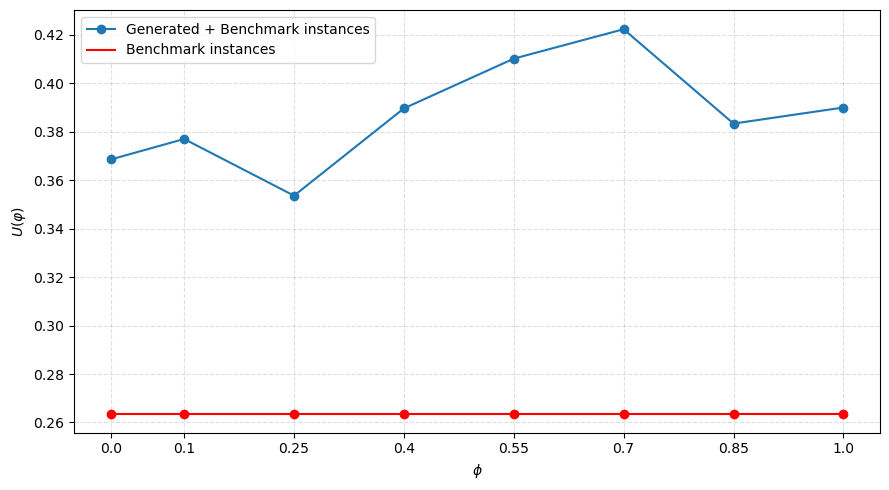

In [32]:
import pandas as pd
import matplotlib.pyplot as plt

methods   = ['insert', 'swap', 'two_opt']
suffixes  = ['0', '0_1', '0_25', '0_4', '0_55', '0_7', '0_85', '1']
phi_value = {'0': 0.0, '0_1': 0.1, '0_25': 0.25, '0_4': 0.4, '0_55': 0.55, '0_7': 0.7, '0_85': 0.85, '1': 1.0}

def load_instances(method: str, suffix: str):
    filename = f"{method}_ls_1000_gens_NS2_{suffix}.npz"
    
    if suffix == '0_85':
        path = f"results/{filename}"
    else:
        path = f"changing-phi/{filename}"

    try:
        return np.load(path)['data']
    except FileNotFoundError:
        raise FileNotFoundError(f"No se pudo cargar {filename} en la ruta: {path}")
    except Exception as e:
        raise RuntimeError(f"Error al cargar {path}: {e}")

def compute_U_by_phi_with_train() -> dict:
    U_by_phi = {}
    for s in suffixes:
        arrays = [load_instances(m, s) for m in methods]
        arrays.append(training_set)
        instances_phi = np.concatenate(arrays, axis=0)

        desc_phi = compute_descriptors_NS_AE(instances_phi)
        U_phi = compute_U_metric(desc_phi, scaler, pca, xlim=xlim, ylim=ylim)
        U_by_phi[s] = float(U_phi)

    return U_by_phi

U_with = compute_U_by_phi_with_train()

df_U = pd.DataFrame({
    "phi_suffix": suffixes,
    "phi": [phi_value[s] for s in suffixes],
    "U_with_benchmark": [U_with[s] for s in suffixes],
}).sort_values("phi").reset_index(drop=True)

print(df_U)

plt.figure(figsize=(9,5))

line_main, = plt.plot(
    df_U["phi"], df_U["U_with_benchmark"],
    marker='o',
    label='Generated + Benchmark instances'
)

plt.plot(
    [0, 1], [0.2637, 0.2637],
    color='red',
    linestyle=line_main.get_linestyle(),
    linewidth=line_main.get_linewidth(),
    label='Benchmark instances'
)

plt.plot(
    df_U["phi"], [0.2637] * len(df_U),
    linestyle='None',
    marker=line_main.get_marker(),
    markersize=line_main.get_markersize(),
    markerfacecolor='red',
    markeredgecolor='red',
    label='_nolegend_'
)

plt.xticks(df_U["phi"], [str(v) for v in df_U["phi"]])
plt.xlabel(r"$\phi$")
plt.ylabel(r"$U(\varphi)$")
#plt.title(r"U metric with benchmark instances for different $\phi$")
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()

In [33]:
all_generated_desc = np.concatenate(list(descriptor_dict.values()), axis=0)

original_desc = compute_descriptors_NS_AE(training_set)

all_desc = np.concatenate([all_generated_desc, original_desc], axis=0)

U_all = compute_U_metric(all_desc, scaler, pca, xlim=xlim, ylim=ylim)

print(f"U (all φ + training) = {U_all:.6f}")

U (all φ + training) = 0.403455


Define overlapping instances

In [34]:
from sklearn.metrics import pairwise_distances
import numpy as np

def count_close_neighbors(descriptors, previas=None, threshold=0.03):
    X = np.asarray(descriptors)
    n = len(X)

    if n <= 1:
        within_min = np.full(n, np.inf)
    else:
        d_self = pairwise_distances(X)
        np.fill_diagonal(d_self, np.inf)
        within_min = d_self.min(axis=1)

    if previas is None or len(previas) == 0:
        prev_min = np.full(n, np.inf)
    else:
        P = np.asarray(previas)
        prev_min = pairwise_distances(X, P).min(axis=1)

    has_close = (within_min < threshold) | (prev_min < threshold)

    n_close = int(has_close.sum())
    n_without = n - n_close

    min_global = np.minimum(within_min, prev_min)
    return n_close, n_without, min_global


def overlap_analysis(descriptors, name, threshold=0.03, previas=None, devolver_distancias=False):
    n_close, n_far, dmins = count_close_neighbors(
        descriptors, previas=previas, threshold=threshold
    )
    print(f"{name} — Overlapping instances (<{threshold}): {n_close}, Non-overlapping instances: {n_far}")
    print(f"Overlapping percentage: {n_close*100/(n_close+n_far)}%")
    return (n_close, n_far, dmins) if devolver_distancias else (n_close, n_far)

Compute overlapping instances

In [35]:
# Only generated instances

overlap_analysis(
    compute_descriptors_NS_F(np.concatenate((insert_new_F, swap_new_F, two_opt_new_F))),
    "1000 NS_F in NS_F"
)

overlap_analysis(
    compute_descriptors_NS_F(np.concatenate((insert_new, swap_new, two_opt_new))),
    "1000 NS_AE in NS_F"
)

overlap_analysis(
    compute_descriptors_NS_F(np.concatenate((insert_new, swap_new, two_opt_new,
                                            insert_new_F, swap_new_F, two_opt_new_F))),
    "1000 all in NS_F"
)

overlap_analysis(
    compute_descriptors_NS_AE(np.concatenate((insert_new_F, swap_new_F, two_opt_new_F))),
    "1000 NS_F in NS_AE", threshold=0.3
)

overlap_analysis(
    compute_descriptors_NS_AE(np.concatenate((insert_new, swap_new, two_opt_new))),
    "1000 NS_AE in NS_AE", threshold=0.3
)

overlap_analysis(
    compute_descriptors_NS_AE(np.concatenate((insert_new, swap_new, two_opt_new,
                                            insert_new_F, swap_new_F, two_opt_new_F))),
    "1000 all in NS_AE", threshold=0.3
)

# Only benchmark (without instances)
overlap_analysis(
    compute_descriptors_NS_F(training_set),
    "Solo instances"
)

overlap_analysis(
    compute_descriptors_NS_AE(training_set),
    "Solo instances", threshold=0.3
)

# With benchmark

print("----With benchmark----")

overlap_analysis(
    compute_descriptors_NS_F(np.concatenate((insert_new_F, swap_new_F, two_opt_new_F))),
    "1000 NS_F in NS_F", previas=compute_descriptors_NS_F(training_set)
)

overlap_analysis(
    compute_descriptors_NS_F(np.concatenate((insert_new, swap_new, two_opt_new))),
    "1000 NS_AE in NS_F", previas=compute_descriptors_NS_F(training_set)
)

overlap_analysis(
    compute_descriptors_NS_F(np.concatenate((insert_new, swap_new, two_opt_new,
                                            insert_new_F, swap_new_F, two_opt_new_F))),
    "1000 all in NS_F", previas=compute_descriptors_NS_F(training_set)
)

overlap_analysis(
    compute_descriptors_NS_AE(np.concatenate((insert_new_F, swap_new_F, two_opt_new_F))),
    "1000 NS_F in NS_AE", threshold=0.3, previas=compute_descriptors_NS_AE(training_set)
)

overlap_analysis(
    compute_descriptors_NS_AE(np.concatenate((insert_new, swap_new, two_opt_new))),
    "1000 NS_AE in NS_AE", threshold=0.3, previas=compute_descriptors_NS_AE(training_set)
)

overlap_analysis(
    compute_descriptors_NS_AE(np.concatenate((insert_new, swap_new, two_opt_new,
                                            insert_new_F, swap_new_F, two_opt_new_F))),
    "1000 all in NS_AE", threshold=0.3, previas=compute_descriptors_NS_AE(training_set)
)

1000 NS_F in NS_F — Overlapping instances (<0.03): 12, Non-overlapping instances: 6310
Overlapping percentage: 0.18981335020563114%
1000 NS_AE in NS_F — Overlapping instances (<0.03): 4005, Non-overlapping instances: 1330
Overlapping percentage: 75.07029053420806%
1000 all in NS_F — Overlapping instances (<0.03): 4334, Non-overlapping instances: 7323
Overlapping percentage: 37.17937719824998%
1000 NS_F in NS_AE — Overlapping instances (<0.3): 5674, Non-overlapping instances: 648
Overlapping percentage: 89.75007908889592%
1000 NS_AE in NS_AE — Overlapping instances (<0.3): 34, Non-overlapping instances: 5301
Overlapping percentage: 0.6373008434864105%
1000 all in NS_AE — Overlapping instances (<0.3): 5859, Non-overlapping instances: 5798
Overlapping percentage: 50.26164536330102%
Solo instances — Overlapping instances (<0.03): 1091, Non-overlapping instances: 2609
Overlapping percentage: 29.486486486486488%
Solo instances — Overlapping instances (<0.3): 1152, Non-overlapping instances: 

(5910, 5747)